In [1]:
import os
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [3]:
import os
import joblib
import pandas as pd

# Project directory
BASE_DIR = r"C:\Users\Virat\Desktop\Credit Risk"

# File paths
MODEL_PATH = os.path.join(
    BASE_DIR,
    "model",
    "credit_risk_model.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "model",
    "preprocessor.pkl"
)

DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "credit_risk_cleaned.csv"
)

# Load trained model
trained_model = joblib.load(MODEL_PATH)

# Load preprocessor
preprocessor = joblib.load(PREPROCESSOR_PATH)

# Load cleaned dataset
df = pd.read_csv(DATA_PATH)

print("Model loaded successfully")
print("Preprocessor loaded successfully")
print("Dataset shape:", df.shape)

Model loaded successfully
Preprocessor loaded successfully
Dataset shape: (32407, 12)


In [4]:
# Target column
target = "loan_status"

# Numerical features
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Categorical features
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

# Combine all input features
features = numerical_features + categorical_features

# Create X and y
X = df[features]
y = df[target]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 11
X shape: (32407, 11)
y shape: (32407,)


In [5]:
# Transform the input features using the saved preprocessor
X_processed = preprocessor.transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Original shape: (32407, 11)
Processed shape: (32407, 26)


In [6]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for feature in feature_names:
    print(feature)

Number of processed features: 26

Processed features:
num__person_age
num__person_income
num__person_emp_length
num__loan_amnt
num__loan_int_rate
num__loan_percent_income
num__cb_person_cred_hist_length
cat__person_home_ownership_MORTGAGE
cat__person_home_ownership_OTHER
cat__person_home_ownership_OWN
cat__person_home_ownership_RENT
cat__loan_intent_DEBTCONSOLIDATION
cat__loan_intent_EDUCATION
cat__loan_intent_HOMEIMPROVEMENT
cat__loan_intent_MEDICAL
cat__loan_intent_PERSONAL
cat__loan_intent_VENTURE
cat__loan_grade_A
cat__loan_grade_B
cat__loan_grade_C
cat__loan_grade_D
cat__loan_grade_E
cat__loan_grade_F
cat__loan_grade_G
cat__cb_person_default_on_file_N
cat__cb_person_default_on_file_Y


In [7]:
# Convert processed data into a DataFrame
X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

# Display first 5 rows
X_processed_df.head()

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,-1.086250,-1.098252,0.058436,-1.363498,0.037470,-0.659580,-0.940936,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.436952,-1.098252,-0.946004,-0.649020,0.598121,3.745410,-0.692413,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.761601,-0.004711,-0.192674,4.034781,1.362940,3.370517,-0.940936,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.599276,-0.221854,0.811766,4.034781,1.051827,3.557964,-0.443890,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.086250,-1.092383,-0.694894,-1.125339,-1.258834,0.746268,-0.940936,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
# Check the structure of the saved model

print("Model type:")
print(type(trained_model))

print("\nModel steps:")
print(trained_model.named_steps)

Model type:
<class 'sklearn.pipeline.Pipeline'>

Model steps:
{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['person_age', 'person_income',
                                  'person_emp_length', 'loan_amnt',
                                  'loan_int_rate', 'loan_percent_income',
                                  'cb_person_cred_hist_length']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                      

In [19]:
# Get the preprocessing and XGBoost model from the pipeline

preprocessor = trained_model.named_steps["preprocessor"]
xgb_model = trained_model.named_steps["model"]

# Use the already processed data as SHAP background
background = X_processed_df.iloc[:100]

# Create a prediction function for the XGBoost model
def shap_predict(data):
    return xgb_model.predict_proba(data)[:, 1]

# Create SHAP explainer
explainer = shap.Explainer(
    shap_predict,
    background,
    algorithm="permutation"
)

print("SHAP explainer created successfully")

SHAP explainer created successfully


In [20]:
# Select a limited number of processed samples for SHAP
# Using 200 samples keeps the calculation reasonably fast

sample_size = min(200, len(X_processed_df))

X_shap = X_processed_df.iloc[:sample_size]

print("Samples selected for SHAP:", len(X_shap))
print("Features per sample:", X_shap.shape[1])

Samples selected for SHAP: 200
Features per sample: 26


In [21]:
# Calculate SHAP values for the selected samples

shap_values = explainer(X_shap)

print("SHAP values calculated successfully")
print("SHAP values shape:", shap_values.values.shape)

PermutationExplainer explainer: 201it [00:19,  5.15it/s]                         

SHAP values calculated successfully
SHAP values shape: (200, 26)


C:\Users\Virat\AppData\Local\Temp\ipykernel_17000\2709212890.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


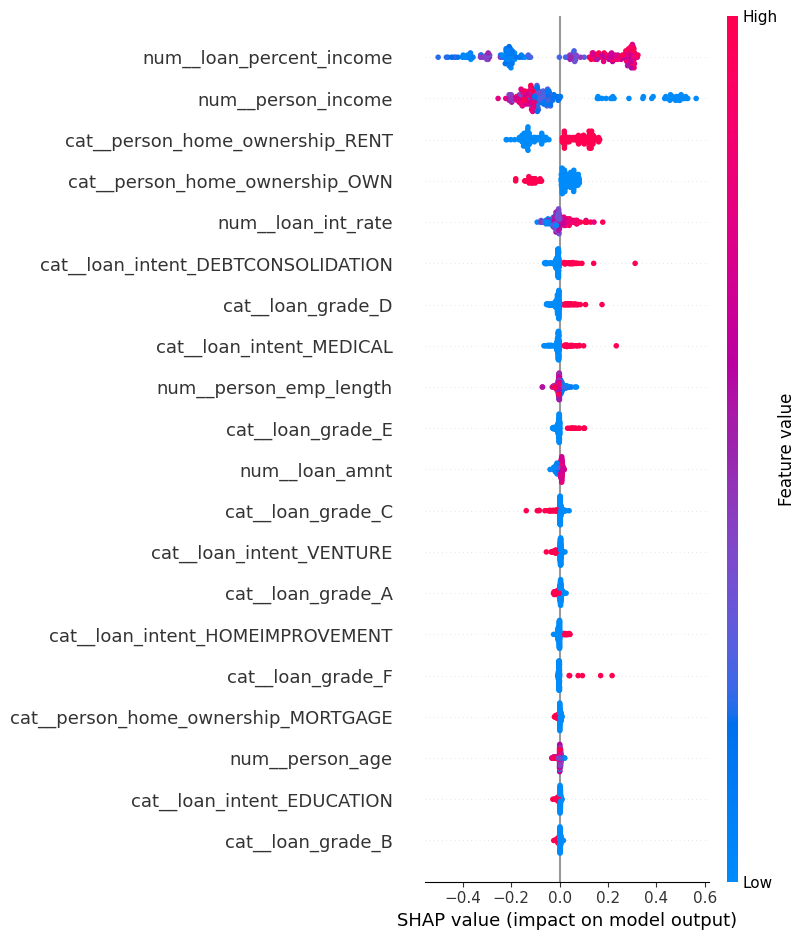

In [22]:
# Create a SHAP summary plot
# This shows how each feature affects the model's predictions

shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=feature_names
)

C:\Users\Virat\AppData\Local\Temp\ipykernel_17000\3906333933.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


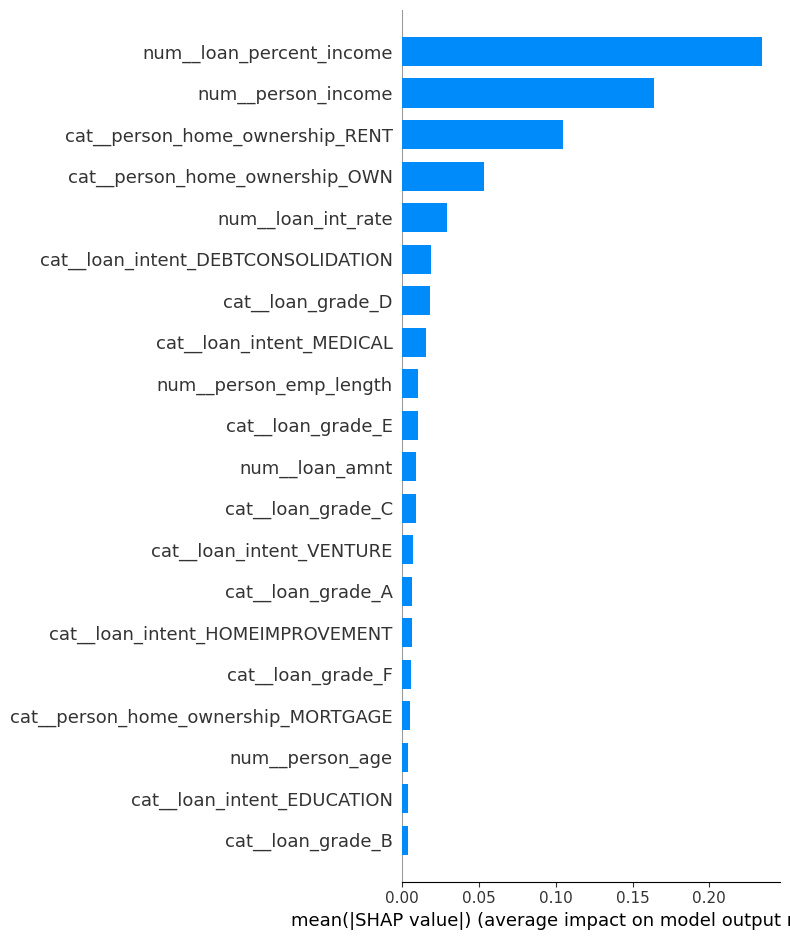

In [23]:
# Create a bar plot showing the average importance
# of each feature in the model

shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [24]:
# Calculate the average absolute SHAP value for each feature

mean_abs_shap = abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="mean_abs_shap",
    ascending=False
)

# Display the top 15 most important features
feature_importance.head(15)

,feature,mean_abs_shap
5,num__loan_percent_income,0.234294
1,num__person_income,0.163782
10,cat__person_home_ownership_RENT,0.104704
9,cat__person_home_ownership_OWN,0.052934
4,num__loan_int_rate,0.029080
11,cat__loan_intent_DEBTCONSOLIDATION,0.018903
20,cat__loan_grade_D,0.017964
14,cat__loan_intent_MEDICAL,0.015165
2,num__person_emp_length,0.010368
21,cat__loan_grade_E,0.010066


In [25]:
# Save feature importance to CSV

OUTPUT_PATH = os.path.join(
    BASE_DIR,
    "model",
    "feature_importance.csv"
)

feature_importance.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Feature importance saved successfully.")
print(OUTPUT_PATH)

Feature importance saved successfully.
C:\Users\Virat\Desktop\Credit Risk\model\feature_importance.csv


In [26]:
# Select one applicant from the dataset
# This applicant will be used for individual SHAP explanation

sample_applicant = X.iloc[[0]]

print("Sample applicant:")
sample_applicant

Sample applicant:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,21,9600,5.0,1000,11.14,0.1,2,OWN,EDUCATION,B,N


In [27]:
# Transform the applicant using the same preprocessor
# used during model training

applicant_processed = preprocessor.transform(
    sample_applicant
)

# Convert to DataFrame
applicant_processed_df = pd.DataFrame(
    applicant_processed,
    columns=feature_names
)

print("Applicant transformed successfully.")
print("Processed shape:", applicant_processed_df.shape)

applicant_processed_df

Applicant transformed successfully.
Processed shape: (1, 26)


,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,-1.08625,-1.098252,0.058436,-1.363498,0.03747,-0.65958,-0.940936,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [28]:
# Generate SHAP explanation for the selected applicant

applicant_shap = explainer(
    applicant_processed_df
)

print("Individual SHAP explanation created successfully.")

Individual SHAP explanation created successfully.


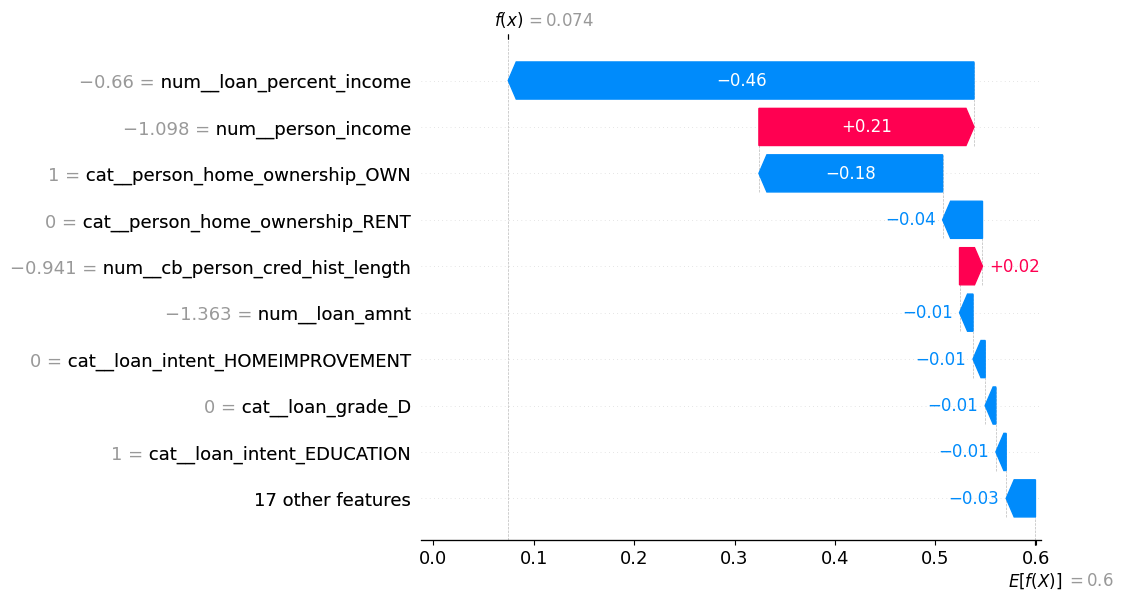

In [29]:
# Create a waterfall plot for the selected applicant
# This shows how each feature contributed to the prediction

shap.waterfall_plot(
    shap.Explanation(
        values=applicant_shap.values[0],
        base_values=applicant_shap.base_values[0],
        data=applicant_processed_df.iloc[0],
        feature_names=feature_names
    )
)

In [30]:
# Create a table showing the contribution of each feature

individual_explanation = pd.DataFrame({
    "feature": feature_names,
    "feature_value": applicant_processed_df.iloc[0].values,
    "shap_value": applicant_shap.values[0]
})

# Calculate absolute SHAP value
individual_explanation["absolute_shap_value"] = (
    individual_explanation["shap_value"].abs()
)

# Sort from most influential to least influential
individual_explanation = individual_explanation.sort_values(
    by="absolute_shap_value",
    ascending=False
)

# Display the top 15 influential features
individual_explanation.head(15)

,feature,feature_value,shap_value,absolute_shap_value
5,num__loan_percent_income,-0.659580,-0.463953,0.463953
1,num__person_income,-1.098252,0.214254,0.214254
9,cat__person_home_ownership_OWN,1.000000,-0.182989,0.182989
10,cat__person_home_ownership_RENT,0.000000,-0.039732,0.039732
6,num__cb_person_cred_hist_length,-0.940936,0.022880,0.022880
3,num__loan_amnt,-1.363498,-0.013438,0.013438
13,cat__loan_intent_HOMEIMPROVEMENT,0.000000,-0.012097,0.012097
20,cat__loan_grade_D,0.000000,-0.010673,0.010673
12,cat__loan_intent_EDUCATION,1.000000,-0.010271,0.010271
11,cat__loan_intent_DEBTCONSOLIDATION,0.000000,-0.008541,0.008541


In [31]:
# Save the individual SHAP explanation to a CSV file

EXPLANATION_PATH = os.path.join(
    BASE_DIR,
    "model",
    "sample_prediction_explanation.csv"
)

individual_explanation.to_csv(
    EXPLANATION_PATH,
    index=False
)

print("Individual explanation saved successfully.")
print(EXPLANATION_PATH)

Individual explanation saved successfully.
C:\Users\Virat\Desktop\Credit Risk\model\sample_prediction_explanation.csv


In [32]:
print("Explainability process completed successfully.")
print()

print("Generated files:")
print("1. model/feature_importance.csv")
print("2. model/sample_prediction_explanation.csv")

Explainability process completed successfully.

Generated files:
1. model/feature_importance.csv
2. model/sample_prediction_explanation.csv
